# 📉 Holt-Winters: Double & Triple Exponential Smoothing

While **SMA** and **EWMA** are great for smoothing data, they have a major flaw: they assume the future will look exactly like the average of the past (a flat line). They cannot handle **Trends** (going up/down) or **Seasonality** (repeating patterns).

**Holt-Winters** solves this by breaking the smoothing process into three parts.



---

## 1. Single Exponential Smoothing (EWMA)
* **What we already know.**
* **Components:** Level ($\ell$).
* **Use Case:** Data with no clear trend or seasonality.
* **Forecast:** A flat line extending into the future.

---

## 2. Double Exponential Smoothing (Holt's Method)
**The Problem:** If you apply EWMA to a stock that is constantly rising, the EWMA line will always be *below* the price (lagging). It doesn't "understand" that the price is moving up.

**The Solution:** Holt added a second equation to track the **Trend (Slope)**.
* **Components:**
    * **Level ($\ell$):** The average value (smoothed).
    * **Trend ($b$):** The rate of change (is it going up or down?).
* **Parameters:**
    * $\alpha$ (Alpha): Smoothing factor for the Level.
    * $\beta$ (Beta): Smoothing factor for the Trend.
* **Forecast:** A straight line going up or down indefinitely.

---

## 3. Triple Exponential Smoothing (Holt-Winters Method)
**The Problem:** Holt's method can follow a trend, but it fails if sales spike every December. It treats that spike as a "trend change" rather than a regular seasonal event.

**The Solution:** Winters added a third equation to track **Seasonality**.
* **Components:**
    * **Level ($\ell$)**
    * **Trend ($b$)**
    * **Seasonality ($s$):** A repeating pattern over a fixed period $L$ (e.g., 12 months).
* **Parameters:**
    * $\alpha$ (Alpha): Level smoothing.
    * $\beta$ (Beta): Trend smoothing.
    * $\gamma$ (Gamma): Seasonal smoothing.
* **Forecast:** A complex wave that follows the trend while repeating the seasonal pattern.

---

## ⚡ The Equations (Conceptual)

1.  **Level:** Current Value = (Data - Seasonality) + (Previous Level + Previous Trend)
    * *Updates the baseline.*
2.  **Trend:** Current Trend = (Current Level - Previous Level) + Previous Trend
    * *Updates the slope/angle.*
3.  **Seasonality:** Current Season = (Data - Level) + Previous Season
    * *Updates the repeating pattern.*

---

## ⚠️ Additive vs. Multiplicative (Again)
Just like in decomposition, we must choose the right method:

* **Additive:** Seasonal peaks stay constant size. (e.g., Sales increase by 100 units every Dec).
* **Multiplicative:** Seasonal peaks grow with the trend. (e.g., Sales increase by 10% every Dec).

---

## 📊 Summary Comparison

| Method | Aka | Handles Trend? | Handles Seasonality? | Parameters |
| :--- | :--- | :--- | :--- | :--- |
| **Single** | SES / EWMA | ❌ No | ❌ No | $\alpha$ |
| **Double** | Holt's | ✅ Yes | ❌ No | $\alpha, \beta$ |
| **Triple** | Holt-Winters | ✅ Yes | ✅ Yes | $\alpha, \beta, \gamma$ |

#### 1) Importing Necessary Libraries:

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.holtwinters import SimpleExpSmoothing, ExponentialSmoothing

#### 2) Loading Data:

In [2]:
df = pd.read_csv('airline_passengers.csv', index_col= 0, parse_dates= True)

In [3]:
df.head()

,Thousands of Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [4]:
df.shape

(144, 1)

In [5]:
df.index

DatetimeIndex(['1949-01-01', '1949-02-01', '1949-03-01', '1949-04-01',
               '1949-05-01', '1949-06-01', '1949-07-01', '1949-08-01',
               '1949-09-01', '1949-10-01',
               ...
               '1960-03-01', '1960-04-01', '1960-05-01', '1960-06-01',
               '1960-07-01', '1960-08-01', '1960-09-01', '1960-10-01',
               '1960-11-01', '1960-12-01'],
              dtype='datetime64[ns]', name='Month', length=144, freq=None)

##### Setting Index Frequency:

Note that our DatetimeIndex does not have a frequency. In order to build a Holt-Winters smoothing model, statsmodels needs to know the frequency of the data (whether it's daily, monthly etc.). Since observations occur at the start of each month, we'll use MS.<br>A full list of time series offset aliases can be found <a href='http://pandas.pydata.org/pandas-docs/stable/user_guide/timeseries.html#offset-aliases'>here</a>.

In [6]:
df.index.freq = 'MS' # "MS" stands for Month Start as our Data Points are all at The First Day of Month.

In [7]:
df.index

DatetimeIndex(['1949-01-01', '1949-02-01', '1949-03-01', '1949-04-01',
               '1949-05-01', '1949-06-01', '1949-07-01', '1949-08-01',
               '1949-09-01', '1949-10-01',
               ...
               '1960-03-01', '1960-04-01', '1960-05-01', '1960-06-01',
               '1960-07-01', '1960-08-01', '1960-09-01', '1960-10-01',
               '1960-11-01', '1960-12-01'],
              dtype='datetime64[ns]', name='Month', length=144, freq='MS')

#### Simple Exponential Smoothing:
`Simple Exponential Smoothing Does Exactly the same calculation as Pandas ewm (exponentially weighted moving averages) method.`

- span = 12
- alpha = 2 / (span + 1)

In [8]:
span = 12
alpha = 2 / (span + 1)

In [9]:
df.head()

,Thousands of Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [10]:
df['EWMA- 12 Months'] = df['Thousands of Passengers'].ewm(alpha= alpha, adjust= False).mean()
df.head(10)

,Thousands of Passengers,EWMA- 12 Months
Month,,
1949-01-01,112,112.000000
1949-02-01,118,112.923077
1949-03-01,132,115.857988
1949-04-01,129,117.879836
1949-05-01,121,118.359861
1949-06-01,135,120.919883
1949-07-01,148,125.086055
1949-08-01,148,128.611277
1949-09-01,136,129.748004


In [11]:
# Simple Exponential Smoothing:

ses = SimpleExpSmoothing(endog= df['Thousands of Passengers'])
results = ses.fit(smoothing_level= alpha, optimized= False)

In [12]:
results.fittedvalues

Month
1949-01-01    112.000000
1949-02-01    112.000000
1949-03-01    112.923077
1949-04-01    115.857988
1949-05-01    117.879836
                 ...    
1960-08-01    474.698368
1960-09-01    494.898619
1960-10-01    496.914216
1960-11-01    491.388952
1960-12-01    475.790652
Freq: MS, Length: 144, dtype: float64

`As we can see, values gives by Simple Exponential Smoothing are exactly same as EWM, just shifted by 1 row.`

In [13]:
results.fittedvalues.shift(-1)

Month
1949-01-01    112.000000
1949-02-01    112.923077
1949-03-01    115.857988
1949-04-01    117.879836
1949-05-01    118.359861
                 ...    
1960-08-01    494.898619
1960-09-01    496.914216
1960-10-01    491.388952
1960-11-01    475.790652
1960-12-01           NaN
Freq: MS, Length: 144, dtype: float64

In [14]:
# Attaching Simple Exponential Smoothing Results as Dataframe Column:

df['Simple_Expo_Smoothing_12mths'] = SimpleExpSmoothing(df['Thousands of Passengers']).fit(smoothing_level= alpha,
                                                                                           optimized= False).fittedvalues.shift(-1)

In [15]:
df.head(10)

,Thousands of Passengers,EWMA- 12 Months,Simple_Expo_Smoothing_12mths
Month,,,
1949-01-01,112,112.000000,112.000000
1949-02-01,118,112.923077,112.923077
1949-03-01,132,115.857988,115.857988
1949-04-01,129,117.879836,117.879836
1949-05-01,121,118.359861,118.359861
1949-06-01,135,120.919883,120.919883
1949-07-01,148,125.086055,125.086055
1949-08-01,148,128.611277,128.611277
1949-09-01,136,129.748004,129.748004


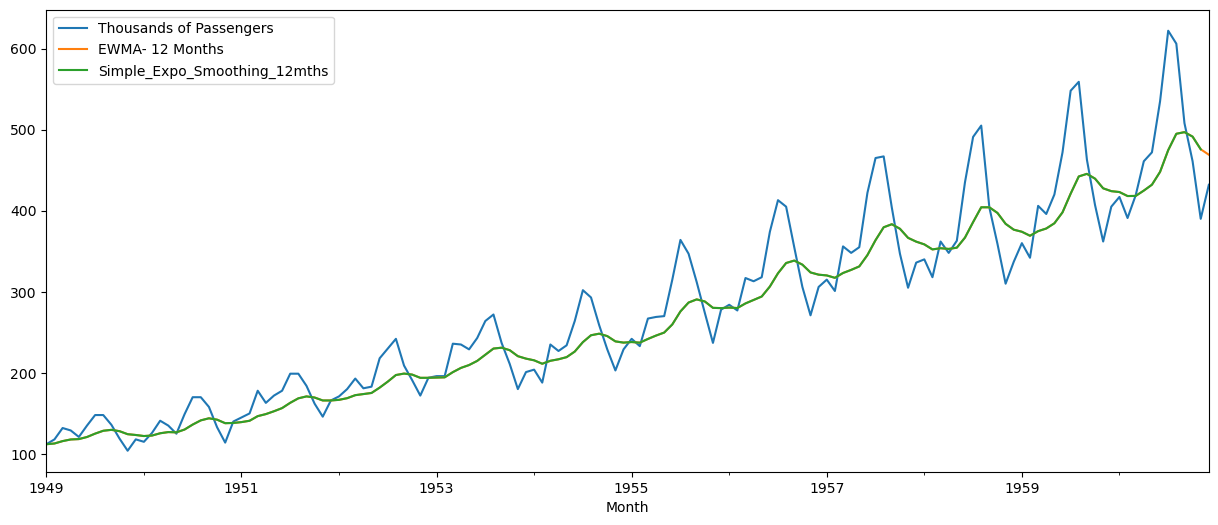

In [16]:
# Plotting EWMA and Simple Exponential Smoothing with Original Data:

df.plot(kind= 'line', figsize= (15,6))
plt.show()

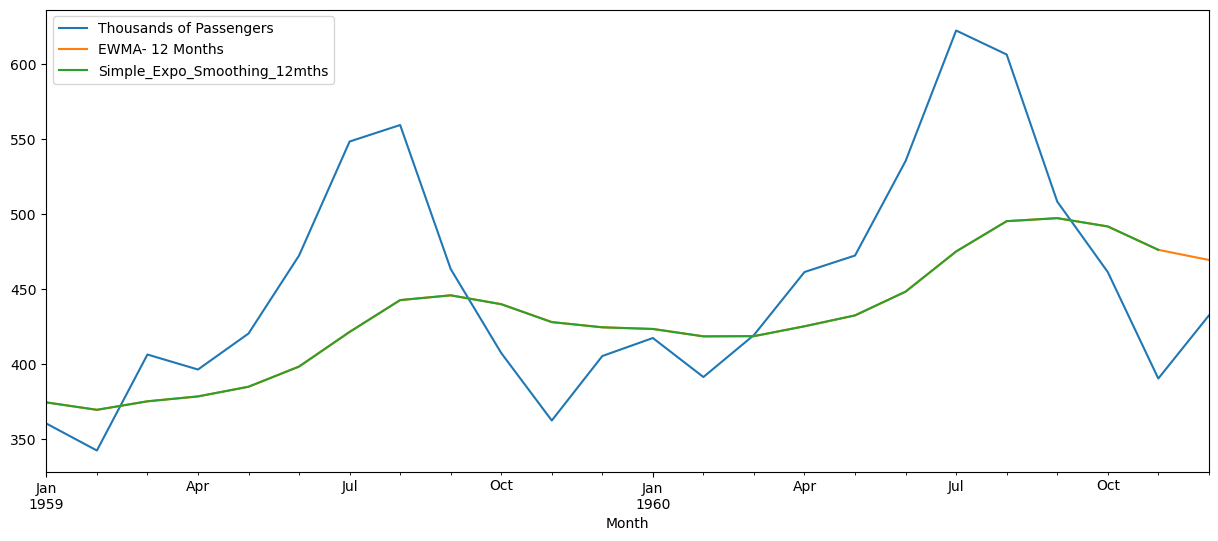

In [17]:
# Zooming in on Grapg By Viewing Only Last 24 Values (Last 2 Years Values):

df[-24:].plot(figsize= (15,6))
plt.show()

#### Double Exponential Smoothing:

In [18]:
# Exponential Smoothing Using Additive Trend:

df['Double_Expo_Smoothing_ADD_12mths'] = ExponentialSmoothing(endog= df['Thousands of Passengers'],
                                                             trend= 'add').fit().fittedvalues.shift(-1)

In [19]:
df.head()

,Thousands of Passengers,EWMA- 12 Months,Simple_Expo_Smoothing_12mths,Double_Expo_Smoothing_ADD_12mths
Month,,,,
1949-01-01,112,112.000000,112.000000,114.237765
1949-02-01,118,112.923077,112.923077,120.237765
1949-03-01,132,115.857988,115.857988,134.237765
1949-04-01,129,117.879836,117.879836,131.237765
1949-05-01,121,118.359861,118.359861,123.237766


In [20]:
# Exponential Smoothing Using Multiplicative Trend:

df['Double_Expo_Smoothing_MUL_12mths'] = ExponentialSmoothing(endog= df['Thousands of Passengers'],
                                                             trend= 'mul').fit().fittedvalues.shift(-1)

In [21]:
df.head()

,Thousands of Passengers,EWMA- 12 Months,Simple_Expo_Smoothing_12mths,Double_Expo_Smoothing_ADD_12mths,Double_Expo_Smoothing_MUL_12mths
Month,,,,,
1949-01-01,112,112.000000,112.000000,114.237765,112.049183
1949-02-01,118,112.923077,112.923077,120.237765,118.051818
1949-03-01,132,115.857988,115.857988,134.237765,132.057966
1949-04-01,129,117.879836,117.879836,131.237765,129.056649
1949-05-01,121,118.359861,118.359861,123.237766,121.053136


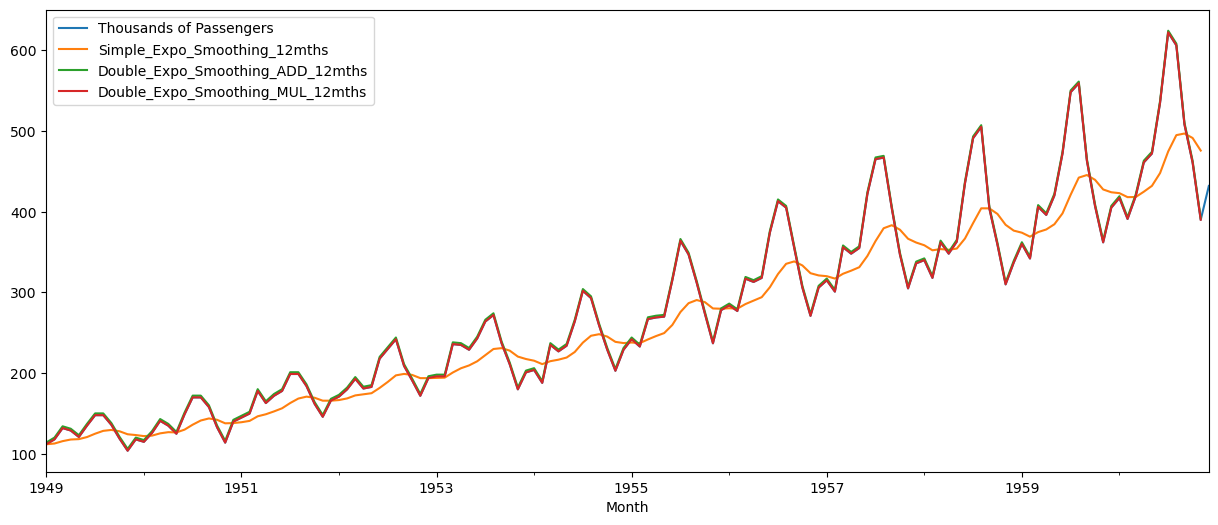

In [22]:
# Comparing Simple Exponential Smoothing With Double Exponential Smoothing (Both Additve ans Multiplicative):

df[['Thousands of Passengers','Simple_Expo_Smoothing_12mths', 'Double_Expo_Smoothing_ADD_12mths', 'Double_Expo_Smoothing_MUL_12mths']].plot(kind= 'line',
                                                                                                                 figsize= (15,6))
plt.show()

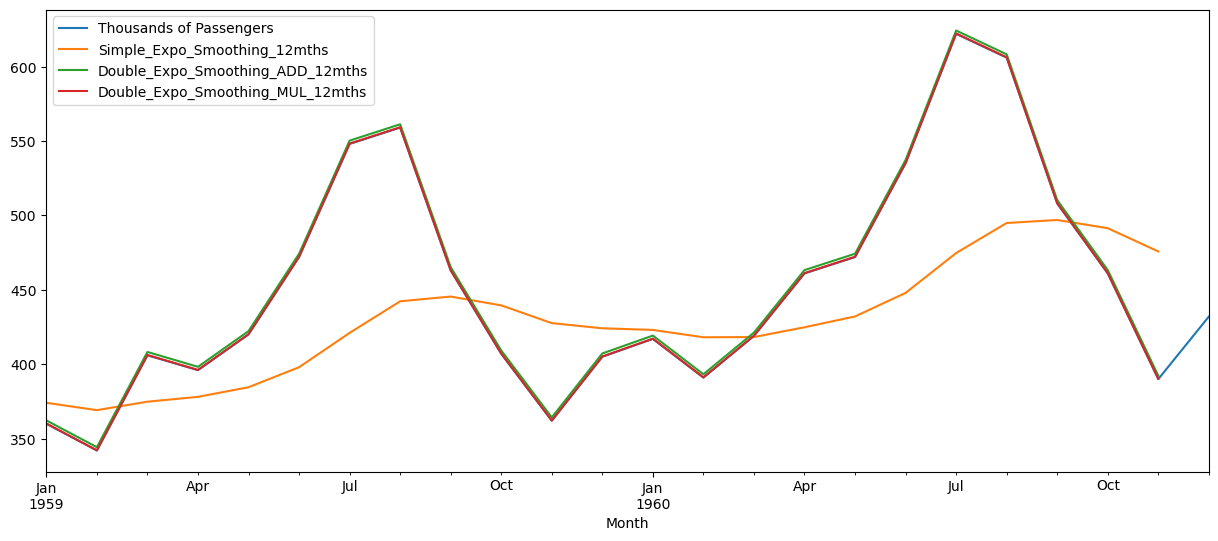

In [23]:
# Zooming in on Grapg By Viewing Only Last 24 Values (Last 2 Years Values):

df[['Thousands of Passengers','Simple_Expo_Smoothing_12mths', 'Double_Expo_Smoothing_ADD_12mths', 'Double_Expo_Smoothing_MUL_12mths']][-24:].plot(kind= 'line',
                                                                                                                 figsize= (15,6))
plt.show()

#### Triple Exponential Smoothing:

In [24]:
# Exponential Smoothing Using Additive Trend and Seasonality:

df['Triple_Expo_Smoothing_ADD_12mths'] = ExponentialSmoothing(endog= df['Thousands of Passengers'],
                                                             trend= 'add', seasonal= 'add',
                                                             seasonal_periods= 12).fit().fittedvalues

In [25]:
df.head()

,Thousands of Passengers,EWMA- 12 Months,Simple_Expo_Smoothing_12mths,Double_Expo_Smoothing_ADD_12mths,Double_Expo_Smoothing_MUL_12mths,Triple_Expo_Smoothing_ADD_12mths
Month,,,,,,
1949-01-01,112,112.000000,112.000000,114.237765,112.049183,111.925105
1949-02-01,118,112.923077,112.923077,120.237765,118.051818,120.103898
1949-03-01,132,115.857988,115.857988,134.237765,132.057966,134.660855
1949-04-01,129,117.879836,117.879836,131.237765,129.056649,131.344474
1949-05-01,121,118.359861,118.359861,123.237766,121.053136,124.619551


In [26]:
# Exponential Smoothing Using Multiplicative Trend and Seasonality:

df['Triple_Expo_Smoothing_MUL_12mths'] = ExponentialSmoothing(endog= df['Thousands of Passengers'],
                                                             trend= 'mul', seasonal= 'mul',
                                                             seasonal_periods= 12).fit().fittedvalues

In [27]:
df.head()

,Thousands of Passengers,EWMA- 12 Months,Simple_Expo_Smoothing_12mths,Double_Expo_Smoothing_ADD_12mths,Double_Expo_Smoothing_MUL_12mths,Triple_Expo_Smoothing_ADD_12mths,Triple_Expo_Smoothing_MUL_12mths
Month,,,,,,,
1949-01-01,112,112.000000,112.000000,114.237765,112.049183,111.925105,111.607892
1949-02-01,118,112.923077,112.923077,120.237765,118.051818,120.103898,118.859379
1949-03-01,132,115.857988,115.857988,134.237765,132.057966,134.660855,133.327115
1949-04-01,129,117.879836,117.879836,131.237765,129.056649,131.344474,127.913468
1949-05-01,121,118.359861,118.359861,123.237766,121.053136,124.619551,120.996166


In [28]:
df.columns

Index(['Thousands of Passengers', 'EWMA- 12 Months',
       'Simple_Expo_Smoothing_12mths', 'Double_Expo_Smoothing_ADD_12mths',
       'Double_Expo_Smoothing_MUL_12mths', 'Triple_Expo_Smoothing_ADD_12mths',
       'Triple_Expo_Smoothing_MUL_12mths'],
      dtype='object')

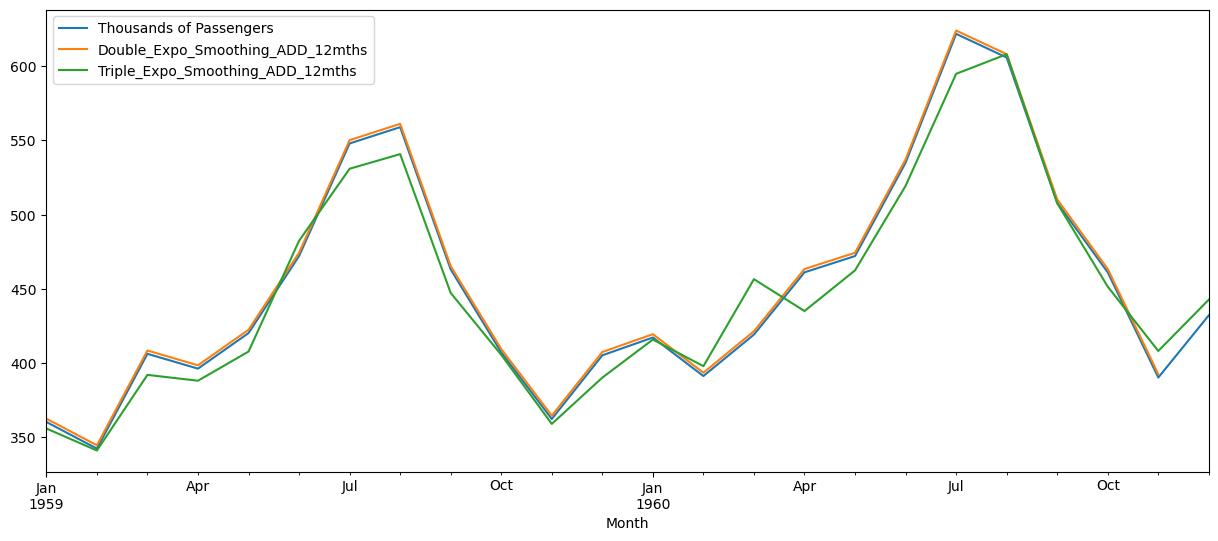

In [29]:
# Comparing Double Exponential Additive to Triple Exponential Additive:

df[['Thousands of Passengers','Double_Expo_Smoothing_ADD_12mths','Triple_Expo_Smoothing_ADD_12mths']][-24:].plot(kind= 'line',
                                                                                                          figsize= (15,6))
plt.show()

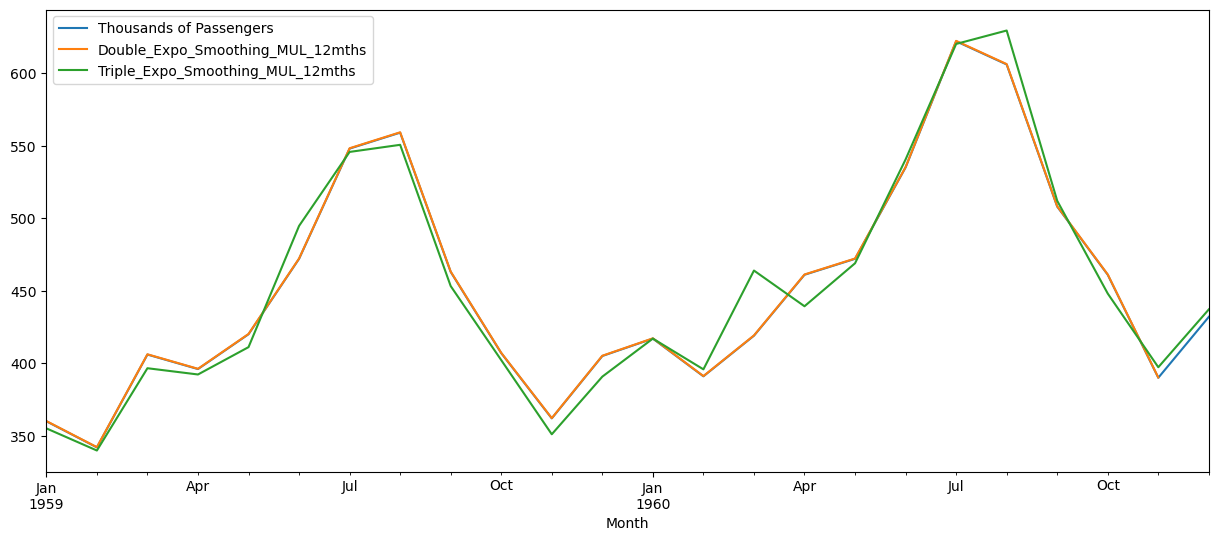

In [30]:
# Comparing Double Exponential Additive to Triple Exponential Multiplicative:

df[['Thousands of Passengers','Double_Expo_Smoothing_MUL_12mths','Triple_Expo_Smoothing_MUL_12mths']][-24:].plot(kind= 'line',
                                                                                                          figsize= (15,6))
plt.show()

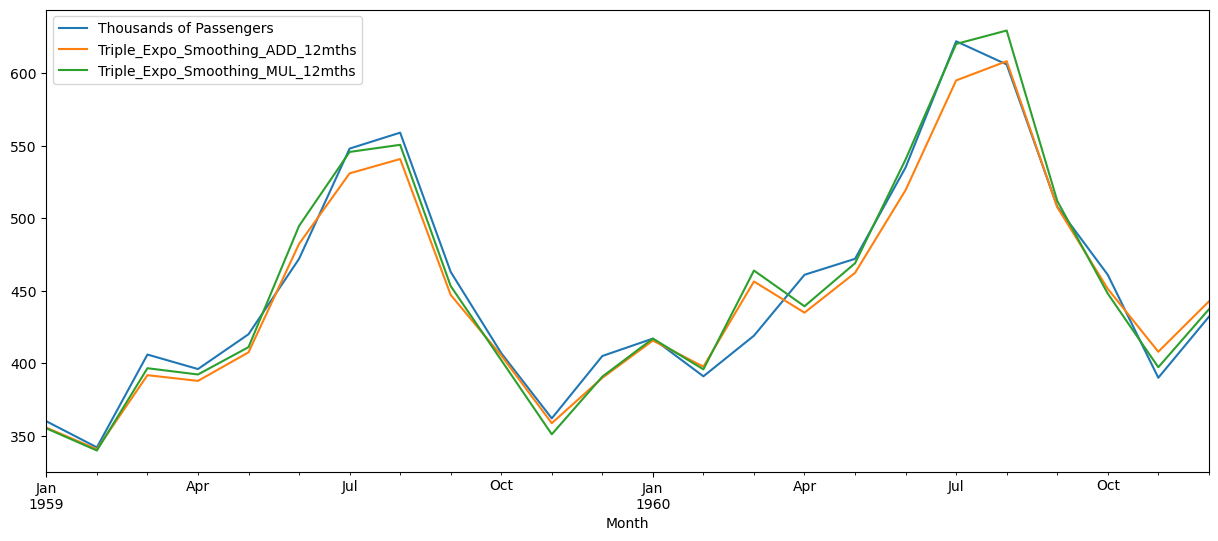

In [31]:
# Comparing Triple Exponential Additive to Triple Exponential Multiplicative:

df[['Thousands of Passengers','Triple_Expo_Smoothing_ADD_12mths','Triple_Expo_Smoothing_MUL_12mths']][-24:].plot(kind= 'line',
                                                                                                          figsize= (15,6))
plt.show()